# Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.experimental import enable_iterative_imputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

# Loading Data

In [6]:
df=pd.read_excel('C:/Users/fccat/Desktop/MUDI Lab/Data/Data.xlsx', sheet_name='Foglio1')
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,...,M Letto-sedia-carrozzina_post_int,M WC_post_int,M Vasca o doccia_post_int,C Rapporto con gli altri_post_int,C Soluzione di problemi_post_int,C Memoria_post_int,Deambulazione.1,Ausili,Outcome sociale,Peso Assistenziale
0,Monza e Brianza,715.15,81.51,postero-laterale,79,F,Pensionato che ha lavorato,28.0,5,2,...,7,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,6,6,2,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,6,6,1,7.0,7.0,7.0,Con supervisore,2 canadesi,Domicilio con parenti,Meno di 3h
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,7,6,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1706,Savona,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,...,7,6,4,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1707,Milano,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,...,6,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
1708,Cuneo,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h


## Dataframe Overview

In [469]:
df.info() # Dataframe Overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710 entries, 0 to 1709
Data columns (total 63 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Residenza                                            1710 non-null   object 
 1   Diagnosi alla dimissione (ICD code)                  1710 non-null   float64
 2   Procedura (ICD code)                                 1710 non-null   float64
 3   Accesso chirurgico                                   1708 non-null   object 
 4   Età                                                  1710 non-null   int64  
 5   Sesso                                                1710 non-null   object 
 6   Professione                                          1710 non-null   object 
 7   BMI Pre-Int                                          1706 non-null   float64
 8   Durata ricovero pre int                              1710 non-null  

In [470]:
# Statistiche descrittive
print(df.describe(include='all'))

       Residenza  Diagnosi alla dimissione (ICD code)  Procedura (ICD code)  \
count       1710                          1710.000000           1710.000000   
unique        94                                  NaN                   NaN   
top       Genova                                  NaN                   NaN   
freq         380                                  NaN                   NaN   
mean         NaN                           715.158965             81.529035   
std          NaN                             0.016243              0.014451   
min          NaN                           715.150000             81.510000   
25%          NaN                           715.150000             81.510000   
50%          NaN                           715.160000             81.540000   
75%          NaN                           715.160000             81.540000   
max          NaN                           715.260000             81.540000   

       Accesso chirurgico          Età Sesso       

In [471]:
# Controllo duplicati nelle colonne
print(df.columns[df.columns.duplicated()])

Index([], dtype='object')


In [472]:
# Controllo duplicati nelle righe
print(df.duplicated().sum())

0


# Data Cleaning

## Conversione formato delle colonne

In [473]:
df.dtypes

Residenza                               object
Diagnosi alla dimissione (ICD code)    float64
Procedura (ICD code)                   float64
Accesso chirurgico                      object
Età                                      int64
                                        ...   
C Memoria_post_int                     float64
Deambulazione.1                         object
Ausili                                  object
Outcome sociale                         object
Peso Assistenziale                      object
Length: 63, dtype: object

In [474]:
df["Procedura (ICD code)"] = df["Procedura (ICD code)"].astype("object")
df["Diagnosi alla dimissione (ICD code)"] = df["Diagnosi alla dimissione (ICD code)"].astype("object")
df["ASA"] = df["ASA"].astype("object")

df["M Letto-sedia-carrozzina"] = pd.to_numeric(df["M Letto-sedia-carrozzina"], errors="coerce")
df["M WC"] = pd.to_numeric(df["M WC"], errors="coerce")
df["M Vasca o doccia"] = pd.to_numeric(df["M Vasca o doccia"], errors="coerce")


df["Hb ingresso"] = (df["Hb ingresso"].astype(str).str.replace(",", ".")      # sostituisci virgola con punto
)
df["Hb ingresso"] = pd.to_numeric(df["Hb ingresso"], errors="coerce")


df["Giorni_vert_intervento"] = pd.to_numeric(df["Giorni_vert_intervento"].astype(str).str.replace(",", "."), errors="coerce") 



df["M Letto-sedia-carrozzina_post_int"] = pd.to_numeric(df["M Letto-sedia-carrozzina_post_int"], errors="coerce")
df["M WC_post_int"] = pd.to_numeric(df["M WC_post_int"], errors="coerce")
df["M Vasca o doccia_post_int"] = pd.to_numeric(df["M Vasca o doccia_post_int"], errors="coerce")


df.dtypes

Residenza                               object
Diagnosi alla dimissione (ICD code)     object
Procedura (ICD code)                    object
Accesso chirurgico                      object
Età                                      int64
                                        ...   
C Memoria_post_int                     float64
Deambulazione.1                         object
Ausili                                  object
Outcome sociale                         object
Peso Assistenziale                      object
Length: 63, dtype: object

## Missing Values

In [475]:
# Calcolo percentuale di missing per colonna
missing_percent = df.isnull().mean() * 100  

# Ordino dalla colonna con più missing a quella con meno
missing_percent = missing_percent.sort_values(ascending=False)

missing_percent

Condizioni pre-esistenti 7             99.941520
Condizioni pre-esistenti 9             99.941520
Condizioni pre-esistenti 8             99.941520
Condizioni pre-esistenti 6             99.590643
Condizioni pre-esistenti 5             98.011696
                                         ...    
Giorno Intervento                       0.000000
ASA                                     0.000000
Procedura (ICD code)                    0.000000
Diagnosi alla dimissione (ICD code)     0.000000
Residenza                               0.000000
Length: 63, dtype: float64

### Variabili con circa il 5% di Missing values 

In [476]:
# Calcola la percentuale di missing per ogni colonna
missing_percent = df.isna().mean() * 100

# Seleziona solo le colonne con al massimo 6% di missing
cols_to_dropna = missing_percent[missing_percent <= 6].index.tolist()

print("Colonne con <=6% missing su cui possiamo rimuovere le righe:")
print(cols_to_dropna)

# Rimuove le righe che hanno NaN in queste colonne
df = df.dropna(subset=cols_to_dropna)

Colonne con <=6% missing su cui possiamo rimuovere le righe:
['Residenza', 'Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)', 'Accesso chirurgico', 'Età', 'Sesso', 'Professione', 'BMI Pre-Int', 'Durata ricovero pre int', 'ASA', 'Durata intervento', 'Anestesia', 'Rischio bio', 'Trasfusione', 'Giorno Intervento', 'BI', 'FIM', 'M Letto-sedia-carrozzina', 'M WC', 'M Vasca o doccia', 'C Rapporto con gli altri', 'C Soluzione di problemi', 'C Memoria', 'ADL', 'L Autonomia passaggi posturali', 'Deambulazione', 'Vive con', 'Dolore ingresso (VNS)', 'Precedente protesi', 'Farmaci extra', 'Hb ingresso', 'Giorni_vert_intervento', 'Durata ricovero post int', 'Controllo farmacologico del dolore', 'Prevenzione TVP', 'Recupero articolare e trofismo muscolare', 'Training passaggi posturali e trasferimenti', 'Recupero autonomia nel salire e scendere le scale', 'Educazione ad evitare posture e movimenti a rischio', 'BI_post_int', 'FIM_post_int', 'M Letto-sedia-carrozzina_post_int', 'M WC_post_

In [477]:
# Calcolo percentuale di missing per colonna
missing_percent_new = df.isnull().mean() * 100  

# Ordino dalla colonna con più missing a quella con meno
missing_percent_new = missing_percent_new.sort_values(ascending=False)

missing_percent_new

Condizioni pre-esistenti 7    99.934211
Condizioni pre-esistenti 9    99.934211
Condizioni pre-esistenti 8    99.934211
Condizioni pre-esistenti 6    99.539474
Condizioni pre-esistenti 5    97.828947
                                ...    
C Memoria_post_int             0.000000
Deambulazione.1                0.000000
Ausili                         0.000000
Outcome sociale                0.000000
Peso Assistenziale             0.000000
Length: 63, dtype: float64

### CPM

In [478]:
#I valori di Missing Values sarebbero in realtà come "NO"
df["CPM"] = df["CPM"].fillna("No") # Sostituisco i missing in CPM con "No" data la natura della variabile. 

# Calcolo percentuale di missing per colonna
missing_percent_new = df.isnull().mean() * 100  

missing_percent_new = missing_percent_new.sort_values(ascending=False)

missing_percent_new

C:\Users\fccat\AppData\Local\Temp\ipykernel_22144\4198099913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CPM"] = df["CPM"].fillna("No") # Sostituisco i missing in CPM con "No" data la natura della variabile.


Condizioni pre-esistenti 7    99.934211
Condizioni pre-esistenti 9    99.934211
Condizioni pre-esistenti 8    99.934211
Condizioni pre-esistenti 6    99.539474
Condizioni pre-esistenti 5    97.828947
                                ...    
C Memoria_post_int             0.000000
Deambulazione.1                0.000000
Ausili                         0.000000
Outcome sociale                0.000000
Peso Assistenziale             0.000000
Length: 63, dtype: float64

### Condizioni pre-esistenti 1 -> 9

In [ ]:
replace_dict = {
    "Visivo": "Apparato visivo",
    "Malattie della tioride": "Malattie della tiroide",
    "Diabete 1": "Diabete",
    "Diabete 2": "Diabete",
    "Tumori": "Tumore",
    "Tiroide ": "Malattie della tiroide"
} # unifico alcune categorie con errori di battitura o sinonimi

cols_patologie = [
    "Condizioni pre-esistenti 1","Condizioni pre-esistenti 2",
    "Condizioni pre-esistenti 3","Condizioni pre-esistenti 4",
    "Condizioni pre-esistenti 5","Condizioni pre-esistenti 6",
    "Condizioni pre-esistenti 7","Condizioni pre-esistenti 8",
    "Condizioni pre-esistenti 9"
] 

for col in cols_patologie:
    df[col] = df[col].replace(replace_dict)


C:\Users\fccat\AppData\Local\Temp\ipykernel_22144\1363993068.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace(replace_dict)


In [480]:
# Creo la variabile che conta il numero di patologie per paziente pre esistenti
df["N_Patologie"] = df[["Condizioni pre-esistenti 1","Condizioni pre-esistenti 2",
                        "Condizioni pre-esistenti 3","Condizioni pre-esistenti 4",
                        "Condizioni pre-esistenti 5","Condizioni pre-esistenti 6",
                        "Condizioni pre-esistenti 7","Condizioni pre-esistenti 8",
                        "Condizioni pre-esistenti 9"]].notnull().sum(axis=1) 

C:\Users\fccat\AppData\Local\Temp\ipykernel_22144\58763497.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["N_Patologie"] = df[["Condizioni pre-esistenti 1","Condizioni pre-esistenti 2",


In [481]:
# creo la lista di patologie
df["Patologie"] = df[["Condizioni pre-esistenti 1","Condizioni pre-esistenti 2","Condizioni pre-esistenti 3",
                      "Condizioni pre-esistenti 4","Condizioni pre-esistenti 5","Condizioni pre-esistenti 6",
                      "Condizioni pre-esistenti 7","Condizioni pre-esistenti 8" , "Condizioni pre-esistenti 9"]]\
    .apply(lambda x: [p for p in x if pd.notnull(p)], axis=1)

mlb = MultiLabelBinarizer()
dummies = pd.DataFrame(mlb.fit_transform(df["Patologie"]), 
                       columns=mlb.classes_, index=df.index)

# unisco al dataframe
df = pd.concat([df, dummies], axis=1)

C:\Users\fccat\AppData\Local\Temp\ipykernel_22144\2145923396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Patologie"] = df[["Condizioni pre-esistenti 1","Condizioni pre-esistenti 2","Condizioni pre-esistenti 3",


In [482]:
cols_patologie = [
    "Condizioni pre-esistenti 1","Condizioni pre-esistenti 2",
    "Condizioni pre-esistenti 3","Condizioni pre-esistenti 4",
    "Condizioni pre-esistenti 5","Condizioni pre-esistenti 6",
    "Condizioni pre-esistenti 7","Condizioni pre-esistenti 8",
    "Condizioni pre-esistenti 9", "Patologie"
]

df = df.drop(columns=cols_patologie)
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,...,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tiroide,Tumore
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,0,0,1,0,0,0,0,0,0,0
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,0,0,0,0,0,0,0,0,0,0
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,0,0,0,0,0,0,0,0,0,0
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,0,0,0,0,0,0,0,0,0,0
5,Caserta,715.25,81.51,postero-laterale,51,F,Disoccupato (attualmente),25.0,7,2,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,...,0,0,0,0,0,0,0,0,0,0
1706,Savona,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,...,0,0,0,0,0,0,0,0,0,0
1707,Milano,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,...,0,1,1,0,0,1,0,0,0,0
1708,Cuneo,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,...,0,0,0,0,0,0,0,0,0,0


In [483]:
# Unifica le patologie ancora simili
if "Tiroide" in df.columns and "Malattie della tiroide" in df.columns:
    df["Malattie della tiroide"] = df[["Malattie della tiroide", "Tiroide"]].max(axis=1)
    df = df.drop(columns=["Tiroide"])


In [484]:
# Calcolo percentuale di missing per colonna
missing_percent_new = df.isnull().mean() * 100  

# Ordino dalla colonna con più missing a quella con meno
missing_percent_new = missing_percent_new.sort_values(ascending=False)

missing_percent_new

Terapia farmacologica              20.460526
Recupero piena autonomia in ADL    16.776316
Residenza                           0.000000
Accesso chirurgico                  0.000000
Età                                 0.000000
                                     ...    
Malattie infettive                  0.000000
Osteoporosi                         0.000000
Parkinson                           0.000000
Psiche                              0.000000
Tumore                              0.000000
Length: 83, dtype: float64

### Recupero piena autonomia in ADL

In [485]:
df["Recupero piena autonomia in ADL"].unique()

array([nan, 'Sì'], dtype=object)

In [ ]:
#I valori di Missing Values sarebbero in realtà come "No"
df["Recupero piena autonomia in ADL"] = df["Recupero piena autonomia in ADL"].fillna("No") # Sostituisco i missing in Recupero piena autonomia in ADL con "No" data la natura della variabile. 

# Calcolo percentuale di missing per colonna
missing_percent_new = df.isnull().mean() * 100  

missing_percent_new = missing_percent_new.sort_values(ascending=False)

missing_percent_new

Terapia farmacologica                  20.460526
Diagnosi alla dimissione (ICD code)     0.000000
Residenza                               0.000000
Accesso chirurgico                      0.000000
Età                                     0.000000
                                         ...    
Malattie infettive                      0.000000
Osteoporosi                             0.000000
Parkinson                               0.000000
Psiche                                  0.000000
Tumore                                  0.000000
Length: 83, dtype: float64

### Terapia farmacologica

In [487]:
df["Terapia farmacologica"].unique()

array(['In parte', 'Sì', nan, 'Non risulta', 'Si', 'No'], dtype=object)

In [488]:
df["Terapia farmacologica"] = df["Terapia farmacologica"].replace({
    "Sì": "Si",
    "Non risulta": "No"
}) # uniformo valori

df["Terapia farmacologica"].unique()

array(['In parte', 'Si', nan, 'No'], dtype=object)

- Per trattare i missing di "Terapia farmacologica" decido di fare imputazione "Model-Based". Per fare ciò bisogna prima pulire definitivamente tutte le altre variabili

# Feature Eng. and Encoding

In [489]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,...,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,0,0,0,1,0,0,0,0,0,0
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,0,0,0,0,0,0,0,0,0,0
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,0,0,0,0,0,0,0,0,0,0
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,0,0,0,0,0,0,0,0,0,0
5,Caserta,715.25,81.51,postero-laterale,51,F,Disoccupato (attualmente),25.0,7,2,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,...,0,0,0,0,0,0,0,0,0,0
1706,Savona,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,...,0,0,0,0,0,0,0,0,0,0
1707,Milano,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,...,0,0,1,1,0,0,1,0,0,0
1708,Cuneo,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,...,0,0,0,0,0,0,0,0,0,0


### Residenza 

In [490]:
df["Residenza"].unique() 
# Non ci sono errori di battitura ne da correggere

array(['Como', 'Monza e Brianza', 'Milano', 'Caserta', 'Lecco', 'Catania',
       'Reggio di Calabria', 'Taranto', 'Sondrio', 'Padova', 'Sassari',
       'Pavia', 'Lecce', 'Varese', 'Bari', 'Biella', 'Salerno', 'Vicenza',
       'Torino', 'Siracusa', 'Piacenza', 'Genova', 'Trapani', 'Palermo',
       'Vercelli', 'La Spezia', 'Lucca', 'Ancona', 'Brindisi', 'Napoli',
       'Avellino', 'Campobasso', 'Ascoli Piceno', 'Cagliari', 'Foggia',
       'Messina', 'Novara', 'Verbano-Cusio-Ossola', 'Olbia-Tempio',
       'Ragusa', 'Potenza', 'Savona', 'Cosenza', 'Alessandria', 'Pisa',
       'Grosseto', 'Catanzaro', 'Bergamo', 'Ravenna', 'Chieti', 'Roma',
       'Lodi', 'Belluno', 'Latina', 'Viterbo', 'Perugia', 'Vibo Valentia',
       "Reggio nell'Emilia", 'Pescara', 'Teramo', 'Pordenone',
       'Bolzano-Bozen', 'Trieste', 'Cuneo', 'Barletta-Andria-Trani',
       'Frosinone', 'Brescia', 'Benevento', 'Imperia', 'Firenze',
       'Matera', 'Agrigento', 'Trento', 'Cremona', 'Fermo', 'Verona',
     

In [491]:
# Lista province Lombardia
lombardia = ['Como', 'Monza e Brianza', 'Milano', 'Lecco', 'Sondrio',
             'Pavia', 'Varese', 'Bergamo', 'Lodi', 'Brescia',
             'Cremona', 'Mantova']

# Creazione colonna binaria
df['Residenza_Lombardia'] = df['Residenza'].apply(lambda x: 'Lombardia' if x in lombardia else 'Fuori Lombardia')

# Controllo distribuzione
df['Residenza_Lombardia'].value_counts()


Residenza_Lombardia
Fuori Lombardia    957
Lombardia          563
Name: count, dtype: int64

In [492]:
df["Residenza_Lombardia"].unique()

array(['Lombardia', 'Fuori Lombardia'], dtype=object)

In [493]:
# Variabile numerica: 1 = Lombardia, 0 = Fuori Lombardia
df['Residenza_Lombardia_cat'] = df['Residenza_Lombardia'].apply(lambda x: 1 if x == 'Lombardia' else 0)

# Controllo
df['Residenza_Lombardia_cat'].value_counts()


Residenza_Lombardia_cat
0    957
1    563
Name: count, dtype: int64

### Diagnosi alla dimissione (ICD code)


In [494]:
df["Diagnosi alla dimissione (ICD code)"].unique()

array([715.16, 715.15, 715.25, 715.26], dtype=object)

In [495]:
# Trasformiamo ICD code in stringa (per sicurezza)
df['Diagnosi_ICD'] = df['Diagnosi alla dimissione (ICD code)'].astype(str)

# One-Hot Encoding con 0/1
df = pd.get_dummies(df, columns=['Diagnosi_ICD'], prefix='Diagnosi_ICD', dtype=int)

# Visualizziamo le prime righe per controllo
df.head()


,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,...,Osteoporosi,Parkinson,Psiche,Tumore,Residenza_Lombardia,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,0,0,0,0,Lombardia,1,0,1,0,0
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,0,0,0,0,Lombardia,1,0,1,0,0
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,0,0,0,0,Lombardia,1,1,0,0,0
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,0,0,0,0,Lombardia,1,0,1,0,0
5,Caserta,715.25,81.51,postero-laterale,51,F,Disoccupato (attualmente),25.0,7,2,...,0,0,0,0,Fuori Lombardia,0,0,0,1,0


### Procedura (ICD code)

In [496]:
df["Procedura (ICD code)"].unique()

array([81.54, 81.51], dtype=object)

In [497]:
# Trasformiamo Procedura ICD in stringa (per sicurezza)
df['Procedura_ICD'] = df['Procedura (ICD code)'].astype(str)

# One-Hot Encoding con 0/1
df = pd.get_dummies(df, columns=['Procedura_ICD'], prefix='Procedura_ICD', dtype=int)

# Controllo
df.head()


,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,...,Psiche,Tumore,Residenza_Lombardia,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,0,0,Lombardia,1,0,1,0,0,0,1
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,0,0,Lombardia,1,0,1,0,0,0,1
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,0,0,Lombardia,1,1,0,0,0,1,0
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,0,0,Lombardia,1,0,1,0,0,0,1
5,Caserta,715.25,81.51,postero-laterale,51,F,Disoccupato (attualmente),25.0,7,2,...,0,0,Fuori Lombardia,0,0,0,1,0,1,0


### Accesso chirurgico

In [498]:
df["Accesso chirurgico"].unique()

array(['pararotuleo', 'postero-laterale', 'anteriore', 'midvastus',
       'laterale diretto'], dtype=object)

In [499]:
# One-hot encoding su Accesso chirurgico
df = pd.get_dummies(df, columns=["Accesso chirurgico"], prefix="AccessoChir", dtype=int)

df


,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,...,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale
1,Como,715.16,81.54,79,F,Pensionato che ha lavorato,24.0,6,2,95.0,...,1,0,0,0,1,0,0,0,1,0
2,Monza e Brianza,715.16,81.54,73,F,Pensionato che ha lavorato,26.0,6,2,121.0,...,1,0,0,0,1,0,0,0,1,0
3,Milano,715.15,81.51,73,F,Pensionato che ha lavorato,23.0,6,1,88.0,...,0,0,0,1,0,0,0,0,0,1
4,Milano,715.16,81.54,81,F,Pensionato che ha lavorato,38.0,6,2,99.0,...,1,0,0,0,1,0,0,0,1,0
5,Caserta,715.25,81.51,51,F,Disoccupato (attualmente),25.0,7,2,123.0,...,0,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,63,M,Pensionato che ha lavorato,26.0,5,1,68.0,...,0,0,0,1,0,1,0,0,0,0
1706,Savona,715.16,81.54,60,M,Imprenditore - Libero Professionista,26.0,3,2,31.0,...,1,0,0,0,1,0,0,0,1,0
1707,Milano,715.25,81.51,79,F,Pensionato che ha lavorato,21.0,5,2,96.0,...,0,1,0,1,0,0,1,0,0,0
1708,Cuneo,715.16,81.54,49,M,Imprenditore - Libero Professionista,24.0,4,2,72.0,...,1,0,0,0,1,0,0,0,1,0


### Sesso

In [500]:
df["Sesso"].unique()

array(['F', 'F ', 'M', 'M '], dtype=object)

In [501]:
# Rimuovo spazi bianchi
df['Sesso'] = df['Sesso'].str.strip()

# Trasformo in variabile binaria (1 = maschio, 0 = femmina)
df['Sesso_bin'] = df['Sesso'].map({'M': 1, 'F': 0})


In [502]:
df["Sesso"].unique()

array(['F', 'M'], dtype=object)

In [503]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,...,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Sesso_bin
1,Como,715.16,81.54,79,F,Pensionato che ha lavorato,24.0,6,2,95.0,...,0,0,0,1,0,0,0,1,0,0
2,Monza e Brianza,715.16,81.54,73,F,Pensionato che ha lavorato,26.0,6,2,121.0,...,0,0,0,1,0,0,0,1,0,0
3,Milano,715.15,81.51,73,F,Pensionato che ha lavorato,23.0,6,1,88.0,...,0,0,1,0,0,0,0,0,1,0
4,Milano,715.16,81.54,81,F,Pensionato che ha lavorato,38.0,6,2,99.0,...,0,0,0,1,0,0,0,1,0,0
5,Caserta,715.25,81.51,51,F,Disoccupato (attualmente),25.0,7,2,123.0,...,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,63,M,Pensionato che ha lavorato,26.0,5,1,68.0,...,0,0,1,0,1,0,0,0,0,1
1706,Savona,715.16,81.54,60,M,Imprenditore - Libero Professionista,26.0,3,2,31.0,...,0,0,0,1,0,0,0,1,0,1
1707,Milano,715.25,81.51,79,F,Pensionato che ha lavorato,21.0,5,2,96.0,...,1,0,1,0,0,1,0,0,0,0
1708,Cuneo,715.16,81.54,49,M,Imprenditore - Libero Professionista,24.0,4,2,72.0,...,0,0,0,1,0,0,0,1,0,1


### Professione

In [504]:
df["Professione"].unique()

array(['Pensionato che ha lavorato', 'Disoccupato (attualmente)',
       'Casalinga (che non ha mai svolto lavoro retribuito)',
       'Impiegato, insegnante',
       'Altro (che non ha mai svolto lavoro retribuito)',
       'Operaio, salariato agricolo, altro lavoratore', 'Dirigente',
       'Casalinga (che ha svolto lavoro retribuito)',
       'Imprenditore - Libero Professionista',
       'Invalido, inabile (anche se pensionato)',
       'Artigiano, coltivatore diretto, commerciante',
       'Altro (che ha svolto lavoro retribuito)',
       'Artigiano, Coltivatore Diretto, Commerciante',
       'Casalinga (che non ha mai ha svolto lavoro retribuito)',
       'pensionato che ha lavorato', 'Lavorante a domicilio',
       'Coadiuvante in aziende a conduzione familiare',
       'altro (che ha svolto lavoro retribuito)'], dtype=object)

In [505]:
# Prima ripuliamo eventuali spazi e maiuscole/minuscole
df['Professione'] = df['Professione'].str.strip().str.lower()
df["Professione"].unique()

array(['pensionato che ha lavorato', 'disoccupato (attualmente)',
       'casalinga (che non ha mai svolto lavoro retribuito)',
       'impiegato, insegnante',
       'altro (che non ha mai svolto lavoro retribuito)',
       'operaio, salariato agricolo, altro lavoratore', 'dirigente',
       'casalinga (che ha svolto lavoro retribuito)',
       'imprenditore - libero professionista',
       'invalido, inabile (anche se pensionato)',
       'artigiano, coltivatore diretto, commerciante',
       'altro (che ha svolto lavoro retribuito)',
       'casalinga (che non ha mai ha svolto lavoro retribuito)',
       'lavorante a domicilio',
       'coadiuvante in aziende a conduzione familiare'], dtype=object)

In [506]:
# Definiamo le liste
professioni_attive = [
    'operaio, salariato agricolo, altro lavoratore',
    'artigiano, coltivatore diretto, commerciante',
    'imprenditore - libero professionista',
    'lavorante a domicilio',
    'coadiuvante in aziende a conduzione familiare'
]

# Creiamo la variabile binaria
df['Professione_Attiva'] = df['Professione'].apply(lambda x: 1 if x in professioni_attive else 0)
df["Professione_Attiva"].value_counts()

Professione_Attiva
0    1302
1     218
Name: count, dtype: int64

### ASA

In [507]:
df["ASA"].unique()

array([2, 1, 3], dtype=object)

In [508]:
# Converte la colonna in intero
df['ASA'] = df['ASA'].astype(int)
df["ASA"].value_counts()

ASA
2    1330
1     134
3      56
Name: count, dtype: int64

### Anestesia

In [509]:
df["Anestesia"].unique()

array(['Subaracnoidea', 'Anestesia Generale', 'Bi-Block', 'Blended',
       'Anestesia generale'], dtype=object)

In [510]:
# Pulizia: tutto in minuscolo e strip spazi
df['Anestesia'] = df['Anestesia'].str.strip().str.lower()

# Uniformo varianti
df['Anestesia'] = df['Anestesia'].replace({
    'anestesia generale': 'generale',
    'subaracnoidea': 'subaracnoidea',
    'bi-block': 'bi-block',
    'blended': 'blended'
})
df["Anestesia"].unique()

array(['subaracnoidea', 'generale', 'bi-block', 'blended'], dtype=object)

In [511]:
# One-hot encoding con valori 0/1
df = pd.get_dummies(df, columns=['Anestesia'], prefix='Anestesia', dtype=int)

# Controllo colonne create
print(df.filter(like='Anestesia_').head())


   Anestesia_bi-block  Anestesia_blended  Anestesia_generale  \
1                   0                  0                   0   
2                   0                  0                   0   
3                   0                  0                   0   
4                   0                  0                   0   
5                   0                  0                   1   

   Anestesia_subaracnoidea  
1                        1  
2                        1  
3                        1  
4                        1  
5                        0  


In [512]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,...,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Sesso_bin,Professione_Attiva,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea
1,Como,715.16,81.54,79,F,pensionato che ha lavorato,24.0,6,2,95.0,...,0,0,1,0,0,0,0,0,0,1
2,Monza e Brianza,715.16,81.54,73,F,pensionato che ha lavorato,26.0,6,2,121.0,...,0,0,1,0,0,0,0,0,0,1
3,Milano,715.15,81.51,73,F,pensionato che ha lavorato,23.0,6,1,88.0,...,0,0,0,1,0,0,0,0,0,1
4,Milano,715.16,81.54,81,F,pensionato che ha lavorato,38.0,6,2,99.0,...,0,0,1,0,0,0,0,0,0,1
5,Caserta,715.25,81.51,51,F,disoccupato (attualmente),25.0,7,2,123.0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,63,M,pensionato che ha lavorato,26.0,5,1,68.0,...,0,0,0,0,1,0,0,0,0,1
1706,Savona,715.16,81.54,60,M,imprenditore - libero professionista,26.0,3,2,31.0,...,0,0,1,0,1,1,0,0,0,1
1707,Milano,715.25,81.51,79,F,pensionato che ha lavorato,21.0,5,2,96.0,...,1,0,0,0,0,0,0,0,0,1
1708,Cuneo,715.16,81.54,49,M,imprenditore - libero professionista,24.0,4,2,72.0,...,0,0,1,0,1,1,0,0,0,1


### Rischio bio

In [513]:
df["Rischio bio"].unique()

array(['No', 'Non indicato', 'Sì', 'No '], dtype=object)

In [514]:
# Pulizia spazi
df['Rischio_bio_clean'] = df['Rischio bio'].str.strip().str.title()

# Binaria 0/1
df['Rischio_bio'] = df['Rischio_bio_clean'].apply(lambda x: 1 if x == 'Sì' else 0)

# Rimuovo colonna temporanea
df = df.drop(columns=['Rischio_bio_clean'])

# Controllo
print(df['Rischio_bio'].value_counts())


Rischio_bio
0    1500
1      20
Name: count, dtype: int64


### Trasfusione

In [515]:
df["Trasfusione"].unique()

array(['No', 'Sì', 'no'], dtype=object)

In [516]:
# Pulizia spazi e minuscole/maiuscole
df['Trasfusione_clean'] = df['Trasfusione'].str.strip().str.title()

# Binaria 0/1
df['Trasfusione'] = df['Trasfusione_clean'].apply(lambda x: 1 if x == 'Sì' else 0)

# Rimuovo colonna temporanea
df = df.drop(columns=['Trasfusione_clean'])

# Controllo
print(df['Trasfusione'].value_counts())


Trasfusione
0    1318
1     202
Name: count, dtype: int64


### ADL

In [517]:
df["ADL"].unique()

array(['Parzialmente', 'Autonomo', 'Non autonomo',
       'Autonomo, parzialmente'], dtype=object)

In [518]:
# Creazione mapping
adl_map = {
    'Non autonomo': 0,
    'Parzialmente': 1,
    'Autonomo, parzialmente': 2,
    'Autonomo': 3
}

# Trasformazione in numerico
df['ADL_num'] = df['ADL'].map(adl_map)

# Controllo
print(df[['ADL', 'ADL_num']].head())


            ADL  ADL_num
1  Parzialmente        1
2      Autonomo        3
3      Autonomo        3
4      Autonomo        3
5      Autonomo        3


### L Autonomia passaggi posturali

In [519]:
df["L Autonomia passaggi posturali"].unique()

array(['Parzialmente', 'Autonomo', 'Non autonomo',
       'Autonomo, parzialmente', 'autonomo', 'AUtonomo'], dtype=object)

In [520]:
# Pulizia dei valori (spazi e maiuscole)
df['L_Autonomia_clean'] = df['L Autonomia passaggi posturali'].str.strip().str.title()

# Mapping ordinato
autonomia_map = {
    'Non Autonomo': 0,
    'Parzialmente': 1,
    'Autonomo, Parzialmente': 2,
    'Autonomo': 3
}

# Trasformazione numerica
df['L_Autonomia_num'] = df['L_Autonomia_clean'].map(autonomia_map)

# Rimuovo colonna temporanea
df = df.drop(columns=['L_Autonomia_clean'])

# Controllo
print(df[['L Autonomia passaggi posturali', 'L_Autonomia_num']].head())


  L Autonomia passaggi posturali  L_Autonomia_num
1                   Parzialmente                1
2                       Autonomo                3
3                       Autonomo                3
4                       Autonomo                3
5                       Autonomo                3


### Deambulazione

In [521]:
df["Deambulazione"].unique()

array(['Canadesi, assistito', 'Canadesi, autonomo', 'Non indicato',
       'Canadesi, autonomo e assistito', 'Walker, assistito',
       'Canadesi, non indicato se assistito o autonomo',
       ' Canadesi, assistito', 'Walker, autonomo', 'Girello, assistito',
       'Walker, autonomo e assistito', 'Canadesi e Walker',
       'Canadesi e Walker, assistito',
       'Girello, non indicato se assistito o autonomo',
       'Girello, autonomo e assistito'], dtype=object)

In [522]:
# Pulizia dei valori
df['Deambulazione'] = df['Deambulazione'].str.strip()
df["Deambulazione"].unique()

array(['Canadesi, assistito', 'Canadesi, autonomo', 'Non indicato',
       'Canadesi, autonomo e assistito', 'Walker, assistito',
       'Canadesi, non indicato se assistito o autonomo',
       'Walker, autonomo', 'Girello, assistito',
       'Walker, autonomo e assistito', 'Canadesi e Walker',
       'Canadesi e Walker, assistito',
       'Girello, non indicato se assistito o autonomo',
       'Girello, autonomo e assistito'], dtype=object)

In [523]:
# Definisco una mappatura manuale
autonomia_map = {
    'Canadesi, assistito': 0,
    'Walker, assistito': 0,
    'Girello, assistito': 0,
    'Canadesi, autonomo': 1,
    'Walker, autonomo': 1,
    'Girello, autonomo': 1,
    'Canadesi, autonomo e assistito': 0.5,
    'Walker, autonomo e assistito': 0.5,
    'Girello, autonomo e assistito': 0.5,
    'Canadesi e Walker': 0.5,  # misto, non si sa chi aiuta
    'Canadesi e Walker, assistito': 0.5,
    'Canadesi, non indicato se assistito o autonomo': 0.5,
    'Girello, non indicato se assistito o autonomo': 0.5,
    'Non indicato': None  # oppure np.nan
}

# Creo la nuova colonna
df['Deambulazione_autonomia'] = df['Deambulazione'].map(autonomia_map)

# Controllo i risultati
df[['Deambulazione', 'Deambulazione_autonomia']].head(10)


,Deambulazione,Deambulazione_autonomia
1,"Canadesi, assistito",0.0
2,"Canadesi, autonomo",1.0
3,"Canadesi, assistito",0.0
4,"Canadesi, autonomo",1.0
5,Non indicato,NaN
6,"Canadesi, autonomo e assistito",0.5
7,"Canadesi, autonomo",1.0
8,"Canadesi, autonomo e assistito",0.5
9,"Walker, assistito",0.0
10,"Canadesi, autonomo",1.0


In [524]:
# Tolgo i null generati dall'encoding della variabile Deambulazione_autonomia
df = df[df["Deambulazione_autonomia"].notnull()]
df.isnull().sum()

Residenza                              0
Diagnosi alla dimissione (ICD code)    0
Procedura (ICD code)                   0
Età                                    0
Sesso                                  0
                                      ..
Anestesia_subaracnoidea                0
Rischio_bio                            0
ADL_num                                0
L_Autonomia_num                        0
Deambulazione_autonomia                0
Length: 104, dtype: int64

### Vive con

In [525]:
df["Vive con"].unique()

array(['Da solo, ≥65', 'Familiari',
       '≥65 anni e vive con familiare/caregiver in difficoltà', 'Altro',
       'Da solo',
       ' ≥65 anni e vive con familiare/caregiver in difficoltà',
       'Istituto'], dtype=object)

In [526]:
# Pulizia valori
df['Vive_con_clean'] = df['Vive con'].str.strip()

df['Vive_con_clean'] = df['Vive_con_clean'].replace({
    'Da solo, ≥65': 'Da solo',
    ' ≥65 anni e vive con familiare/caregiver in difficoltà': 'Familiari con difficoltà',
    '≥65 anni e vive con familiare/caregiver in difficoltà': 'Familiari con difficoltà'
})

# Codifica numerica (opzione 1: ordinal-like)
vive_map = {
    'Da solo': 0,
    'Familiari': 1,
    'Familiari con difficoltà': 2,
    'Altro': 3,
    'Istituto': 4
}
df['Vive_con_num'] = df['Vive_con_clean'].map(vive_map)

# Controllo
print(df[['Vive con', 'Vive_con_clean', 'Vive_con_num']].drop_duplicates())


                                               Vive con  \
1                                          Da solo, ≥65   
2                                             Familiari   
14    ≥65 anni e vive con familiare/caregiver in dif...   
17                                                Altro   
75                                              Da solo   
815    ≥65 anni e vive con familiare/caregiver in di...   
1051                                           Istituto   

                Vive_con_clean  Vive_con_num  
1                      Da solo             0  
2                    Familiari             1  
14    Familiari con difficoltà             2  
17                       Altro             3  
75                     Da solo             0  
815   Familiari con difficoltà             2  
1051                  Istituto             4  


### Precedente protesi

In [527]:
df["Precedente protesi"].unique()   

array(['si, anca', 'si, ginocchio', 'no', 'si, anca e ginocchio'],
      dtype=object)

In [528]:
# Pulizia valori (togliamo spazi, mettiamo minuscolo)
df["Precedente protesi"] = df["Precedente protesi"].str.strip().str.lower()

# Creiamo le due colonne binarie
df["Protesi_anca"] = df["Precedente protesi"].apply(lambda x: 1 if "anca" in str(x) else 0)
df["Protesi_ginocchio"] = df["Precedente protesi"].apply(lambda x: 1 if "ginocchio" in str(x) else 0)

# Controllo
print(df[["Protesi_anca", "Protesi_ginocchio"]].head())


   Protesi_anca  Protesi_ginocchio
1             1                  0
2             0                  1
3             1                  0
4             0                  1
6             0                  0


### Farmaci extra

In [529]:
df["Farmaci extra"].unique()

array(['No', 'Sì', 'Si', 'Np'], dtype=object)

In [530]:
df["Farmaci extra"] = (
    df["Farmaci extra"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({"Sì": "Si", "Np": "No"})
)
df["Farmaci extra_bin"] = df["Farmaci extra"].map({"No": 0, "Si": 1})


# Imputation Terapia Farmacologica

Creo un dataset alternativo per fare imputazione per la variabile "Terapia farmacologica"

In [531]:
df["Terapia farmacologica"].unique()

array(['In parte', 'Si', nan, 'No'], dtype=object)

In [532]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,...,Anestesia_subaracnoidea,Rischio_bio,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_clean,Vive_con_num,Protesi_anca,Protesi_ginocchio,Farmaci extra_bin
1,Como,715.16,81.54,79,F,pensionato che ha lavorato,24.0,6,2,95.0,...,1,0,1,1,0.0,Da solo,0,1,0,0
2,Monza e Brianza,715.16,81.54,73,F,pensionato che ha lavorato,26.0,6,2,121.0,...,1,0,3,3,1.0,Familiari,1,0,1,0
3,Milano,715.15,81.51,73,F,pensionato che ha lavorato,23.0,6,1,88.0,...,1,0,3,3,0.0,Familiari,1,1,0,0
4,Milano,715.16,81.54,81,F,pensionato che ha lavorato,38.0,6,2,99.0,...,1,0,3,3,1.0,Da solo,0,0,1,0
6,Lecco,715.25,81.51,74,F,pensionato che ha lavorato,17.0,6,3,106.0,...,0,0,1,1,0.5,Familiari,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,63,M,pensionato che ha lavorato,26.0,5,1,68.0,...,1,0,1,1,1.0,Familiari,1,0,0,0
1706,Savona,715.16,81.54,60,M,imprenditore - libero professionista,26.0,3,2,31.0,...,1,0,0,0,0.5,Familiari,1,0,0,0
1707,Milano,715.25,81.51,79,F,pensionato che ha lavorato,21.0,5,2,96.0,...,1,0,1,1,1.0,Da solo,0,1,0,0
1708,Cuneo,715.16,81.54,49,M,imprenditore - libero professionista,24.0,4,2,72.0,...,1,1,1,1,0.5,Familiari,1,0,0,0


In [533]:
# selezioni le colonne numeriche che interessano a fini predittivi
selected_columns = ["Residenza_Lombardia_cat","Diagnosi_ICD_715.15","Diagnosi_ICD_715.16","Diagnosi_ICD_715.25","Diagnosi_ICD_715.26","Procedura_ICD_81.51",
                    "Procedura_ICD_81.54", "AccessoChir_anteriore", "AccessoChir_laterale diretto", "AccessoChir_midvastus","AccessoChir_pararotuleo",
                    "AccessoChir_postero-laterale", "Età", "Sesso_bin", "Professione_Attiva", "BMI Pre-Int", "Durata ricovero pre int", "ASA", 
                    "Durata intervento", "Anestesia_bi-block","Anestesia_blended","Anestesia_generale","Anestesia_subaracnoidea","Rischio_bio","Trasfusione",
                    "BI", "FIM", "M Letto-sedia-carrozzina","M WC","M Vasca o doccia","C Rapporto con gli altri","C Soluzione di problemi","C Memoria",
                    "ADL_num","L_Autonomia_num","Deambulazione_autonomia","Vive_con_num","Dolore ingresso (VNS)","Protesi_anca","Protesi_ginocchio",
                    "Altro apparato digerente","Altro cardiovascolare","Altro cute ed annessi","Altro muscoloscheletrico","Altro respiratorio",
                    "Altro sistema emolinfopoietico","Altro sistema endocrino-metabolico","Altro sistema nervoso centrale","Altro sistema nervoso periferico",
                    "Altro sistema urinario","Anemie","Apnee notturne","Apparato visivo","Artrite reumatoide","Asma","BPCO","Diabete","Dislipidemia",
                    "Fibrillazione atriale","Insufficienza renale cronica", "Ipercol. e/o ipertrig.","Ipertensione arteriosa", "Malattie della tiroide",
                     "Malattie infettive", "Osteoporosi","Parkinson","Psiche","Tumore", "Farmaci extra_bin", "Hb ingresso" ]   
X_per_TF = df[selected_columns] # selezioni le colonne numeriche che ti interessano per imputare Terapie Farmacologiche (TF)

X_per_TF

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,...,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso
1,1,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,9.4
2,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,9.0
3,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
4,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,8.8
6,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,1,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,12.1
1706,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,10.6
1707,1,0,0,1,0,1,0,0,1,0,...,1,1,0,0,1,0,0,0,0,9.3
1708,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0


In [534]:
X_per_TF.isnull().sum()

Residenza_Lombardia_cat    0
Diagnosi_ICD_715.15        0
Diagnosi_ICD_715.16        0
Diagnosi_ICD_715.25        0
Diagnosi_ICD_715.26        0
                          ..
Parkinson                  0
Psiche                     0
Tumore                     0
Farmaci extra_bin          0
Hb ingresso                0
Length: 70, dtype: int64

In [535]:
X_per_TF

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,...,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso
1,1,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,9.4
2,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,9.0
3,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
4,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,8.8
6,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,1,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,12.1
1706,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,10.6
1707,1,0,0,1,0,1,0,0,1,0,...,1,1,0,0,1,0,0,0,0,9.3
1708,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0


Inizio l'imputazione per Terapie Farmacologiche catogarica, per poi renderla numerica adatta all ML dodel per predire le variabili target di interesse

In [536]:
Y_TF= df["Terapia farmacologica"]
Y_TF

1       In parte
2             Si
3            NaN
4       In parte
6             No
          ...   
1705         NaN
1706         NaN
1707          Si
1708         NaN
1709          Si
Name: Terapia farmacologica, Length: 1499, dtype: object

In [537]:
# Label encoding temporaneo della variabile target che è categorica 
mapping = {'No': 0, 'In parte': 1, 'Si': 2}
Y_TF_num_temp = Y_TF.map(mapping)
Y_TF_num_temp

1       1.0
2       2.0
3       NaN
4       1.0
6       0.0
       ... 
1705    NaN
1706    NaN
1707    2.0
1708    NaN
1709    2.0
Name: Terapia farmacologica, Length: 1499, dtype: float64

In [538]:
# concateniamo X_per_TF e Y_TF_num_temp per poter fare l'imputazione con MICE
df_mice = X_per_TF.copy()
df_mice['Terapie_num_temp'] = Y_TF_num_temp

### MICE

In [539]:
# MICE 
mice_imputer = IterativeImputer(random_state=0, max_iter=50)
df_imputed_array = mice_imputer.fit_transform(df_mice)

# converto di nuovo in dataframe
df_imputed = pd.DataFrame(df_imputed_array, columns=df_mice.columns)
df_imputed

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,...,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapie_num_temp
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.4,1.000000
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,2.000000
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.1,1.532050
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.8,1.000000
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.6,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.1,1.540282
1495,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.6,1.598163
1496,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.3,2.000000
1497,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,1.538354


In [540]:
# Riconvertire la variabile imputata in numerica finale
# arrotondiamo i valori perché MICE restituisce numeri continui
Y_TF_imputed_num = df_imputed['Terapie_num_temp'].round().astype(int)

# se vuoi, puoi ricontrollare la distribuzione
Y_TF_imputed_num.value_counts()

Terapie_num_temp
2    1234
1     188
0      77
Name: count, dtype: int64

In [541]:
Y_TF_imputed_num

0       1
1       2
2       2
3       1
4       0
       ..
1494    2
1495    2
1496    2
1497    2
1498    2
Name: Terapie_num_temp, Length: 1499, dtype: int64

Controllo e confronto le distrubuzioni della variabile imputata con quella non imputata

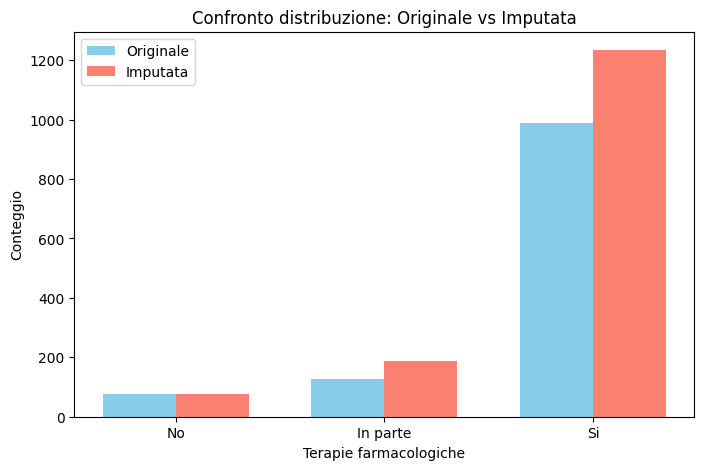

In [542]:
# Controllo e confronto le distrubuzioni della variabile imputata con quella non imputata

# Variabile originale e imputata
Y_TF_orig = Y_TF.copy()
Y_TF_imputed = Y_TF_imputed_num.copy()

# Convertiamo entrambe in categorie
reverse_mapping = {0: 'No', 1: 'In parte', 2: 'Si'}
Y_TF_imputed_cat = Y_TF_imputed.map(reverse_mapping)

# Conteggi per categoria
counts_orig = Y_TF_orig.value_counts().reindex(['No','In parte','Si'])
counts_imputed = Y_TF_imputed_cat.value_counts().reindex(['No','In parte','Si'])

# Posizione delle barre
x = np.arange(len(counts_orig))
width = 0.35

# Creiamo il grafico a barre affiancate
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, counts_orig, width, label='Originale', color='skyblue')
ax.bar(x + width/2, counts_imputed, width, label='Imputata', color='salmon')

# Etichette e titolo
ax.set_xticks(x)
ax.set_xticklabels(['No','In parte','Si'])
ax.set_ylabel('Conteggio')
ax.set_xlabel('Terapie farmacologiche')
ax.set_title('Confronto distribuzione: Originale vs Imputata')
ax.legend()

plt.show()

### KNN

In [543]:
# 
# Label encoding temporaneo per KNN 
mapping = {'No':0, 'In parte':1, 'Si':2}
Y_TF_num_temp = Y_TF.map(mapping)

# Creare dataset combinato per KNN 
df_knn = X_per_TF.copy()
df_knn['Terapie_num_temp'] = Y_TF_num_temp

# KNN Imputer 
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = knn_imputer.fit_transform(df_knn)

# convertiamo di nuovo in dataframe
df_knn_imputed = pd.DataFrame(df_knn_imputed, columns=df_knn.columns)

# Riconvertiamo la variabile imputata in numerica 
Y_TF_knn_num = df_knn_imputed['Terapie_num_temp'].round().astype(int)

# convertiamo in categorie per leggibilità
reverse_mapping = {0:'No', 1:'In parte', 2:'Si'}
Y_TF_knn_cat = Y_TF_knn_num.map(reverse_mapping)



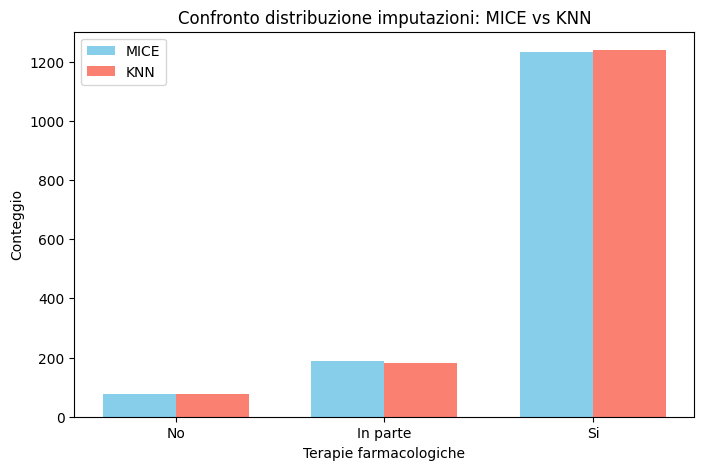

In [544]:
# Grafico a barre affiancate (MICE vs KNN)
counts_mice = Y_TF_imputed_cat.value_counts().reindex(['No','In parte','Si'])
counts_knn = Y_TF_knn_cat.value_counts().reindex(['No','In parte','Si'])

x = np.arange(len(counts_mice))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, counts_mice, width, label='MICE', color='skyblue')
ax.bar(x + width/2, counts_knn, width, label='KNN', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(['No','In parte','Si'])
ax.set_ylabel('Conteggio')
ax.set_xlabel('Terapie farmacologiche')
ax.set_title('Confronto distribuzione imputazioni: MICE vs KNN')
ax.legend()

plt.show()

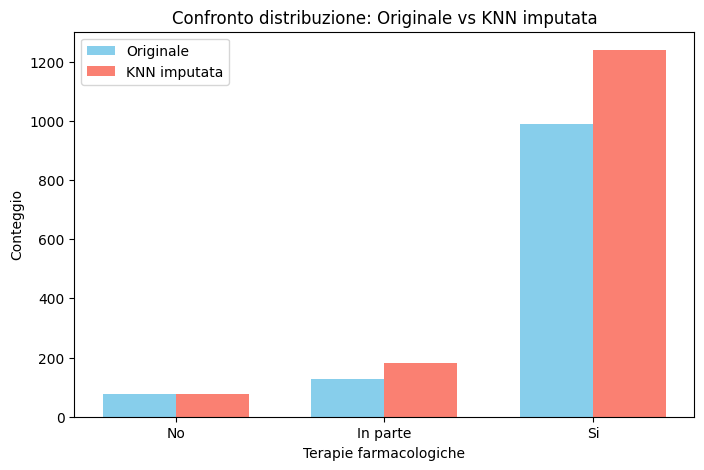

In [545]:
# Grafico a barre affiancate (Originale vs KNN)
counts_orig = Y_TF_orig.value_counts().reindex(['No','In parte','Si'])
counts_knn = Y_TF_knn_cat.value_counts().reindex(['No','In parte','Si'])

x = np.arange(len(counts_orig))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, counts_orig, width, label='Originale', color='skyblue')
ax.bar(x + width/2, counts_knn, width, label='KNN imputata', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(['No','In parte','Si'])
ax.set_ylabel('Conteggio')
ax.set_xlabel('Terapie farmacologiche')
ax.set_title('Confronto distribuzione: Originale vs KNN imputata')
ax.legend()

### Moda

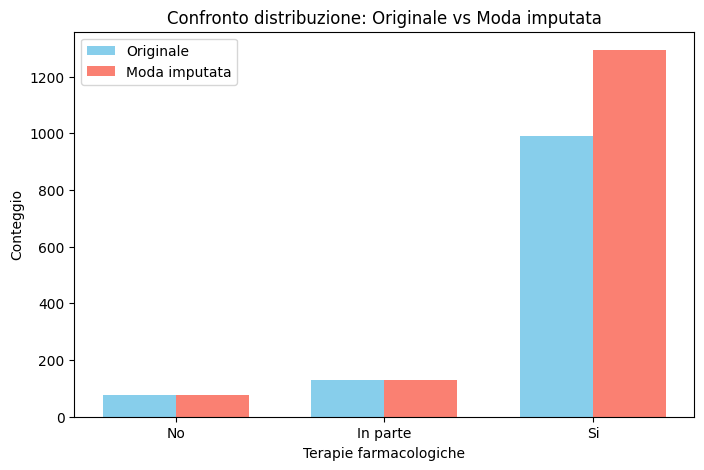

In [546]:
# --- Step 1: Imputazione con la moda ---
imputer_mode = SimpleImputer(strategy='most_frequent')
Y_TF_mode = pd.Series(imputer_mode.fit_transform(Y_TF.values.reshape(-1,1)).ravel(), name='Terapie_farmacologiche')

# --- Step 2: Grafico a barre affiancate (Originale vs Moda imputata) ---
counts_orig = Y_TF.value_counts().reindex(['No','In parte','Si'])
counts_mode = Y_TF_mode.value_counts().reindex(['No','In parte','Si'])

x = range(len(counts_orig))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar([i - width/2 for i in x], counts_orig, width, label='Originale', color='skyblue')
ax.bar([i + width/2 for i in x], counts_mode, width, label='Moda imputata', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(['No','In parte','Si'])
ax.set_ylabel('Conteggio')
ax.set_xlabel('Terapie farmacologiche')
ax.set_title('Confronto distribuzione: Originale vs Moda imputata')
ax.legend()

plt.show()

### Confronto totale

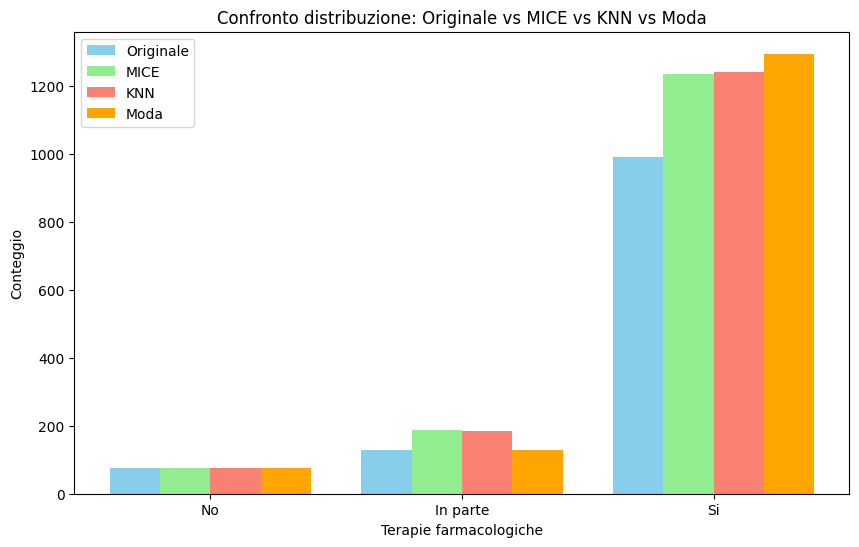

In [547]:
# --- Step 5: Grafico a barre affiancate ---
x = np.arange(len(counts_orig))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5*width, counts_orig, width, label='Originale', color='skyblue')
ax.bar(x - 0.5*width, counts_mice, width, label='MICE', color='lightgreen')
ax.bar(x + 0.5*width, counts_knn, width, label='KNN', color='salmon')
ax.bar(x + 1.5*width, counts_mode, width, label='Moda', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(['No','In parte','Si'])
ax.set_ylabel('Conteggio')
ax.set_xlabel('Terapie farmacologiche')
ax.set_title('Confronto distribuzione: Originale vs MICE vs KNN vs Moda')
ax.legend()

plt.show()

In [548]:



# Calcolo percentuali
perc_orig = counts_orig / counts_orig.sum() * 100
perc_mice = counts_mice / counts_mice.sum() * 100
perc_knn = counts_knn / counts_knn.sum() * 100
perc_mode = counts_mode / counts_mode.sum() * 100

# Creiamo un dataframe comparativo
df_comparison = pd.DataFrame({
    'Originale (%)': perc_orig,
    'MICE (%)': perc_mice,
    'KNN (%)': perc_knn,
    'Moda (%)': perc_mode
})

# Calcolo differenze rispetto all'originale
df_diff = df_comparison.copy()
df_diff['MICE diff (%)'] = df_diff['MICE (%)'] - df_diff['Originale (%)']
df_diff['KNN diff (%)'] = df_diff['KNN (%)'] - df_diff['Originale (%)']
df_diff['Moda diff (%)'] = df_diff['Moda (%)'] - df_diff['Originale (%)']

# Mostriamo risultati
print("Distribuzioni percentuali per categoria:")
print(df_comparison.round(2))
print("\nDifferenze rispetto all'originale (%):")
print(df_diff[['MICE diff (%)', 'KNN diff (%)', 'Moda diff (%)']].round(2))

Distribuzioni percentuali per categoria:
          Originale (%)  MICE (%)  KNN (%)  Moda (%)
No                 6.45      5.14     5.14      5.14
In parte          10.72     12.54    12.21      8.54
Si                82.83     82.32    82.66     86.32

Differenze rispetto all'originale (%):
          MICE diff (%)  KNN diff (%)  Moda diff (%)
No                -1.31         -1.31          -1.31
In parte           1.82          1.49          -2.18
Si                -0.51         -0.18           3.49


In base a questi risultati, MICE appare il metodo più bilanciato, perché mantiene quasi invariata la distribuzione originale e sfrutta le informazioni delle altre variabili.

In [549]:
Y_TF_imputed_num.isnull().sum()

np.int64(0)

In [550]:
X_num = X_per_TF.reset_index(drop=True).copy()
Y_TF_imputed_num = Y_TF_imputed_num.reset_index(drop=True)
X_num['Terapie_farmacologiche'] = Y_TF_imputed_num

In [551]:
X_num.shape

(1499, 71)

In [552]:
# Visualizziamo le prime righe per controllare
X_num['Terapie_farmacologiche'].isnull().sum()  # dovrebbe essere 0


np.int64(0)

In [553]:
X_num.shape

(1499, 71)

In [554]:
# Salvo il dataset pulito e con imputazioni
X_num.to_excel('C:/Users/fccat/Desktop/MUDI Lab/Data_Cleaned_Imputed.xlsx', index=False)

In [555]:
X_num.shape

(1499, 71)

# Dataset Complete

In [556]:
df['Terapia farmacologica'].isnull().sum()  

np.int64(305)

In [557]:
df = df.reset_index(drop=True)
X_num = X_num.reset_index(drop=True)

df['Terapia farmacologica'] = X_num['Terapie_farmacologiche'].values


In [558]:
df['Terapia farmacologica'].isnull().sum()  # dovrebbe essere 0

np.int64(0)

In [559]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,...,Anestesia_subaracnoidea,Rischio_bio,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_clean,Vive_con_num,Protesi_anca,Protesi_ginocchio,Farmaci extra_bin
0,Como,715.16,81.54,79,F,pensionato che ha lavorato,24.0,6,2,95.0,...,1,0,1,1,0.0,Da solo,0,1,0,0
1,Monza e Brianza,715.16,81.54,73,F,pensionato che ha lavorato,26.0,6,2,121.0,...,1,0,3,3,1.0,Familiari,1,0,1,0
2,Milano,715.15,81.51,73,F,pensionato che ha lavorato,23.0,6,1,88.0,...,1,0,3,3,0.0,Familiari,1,1,0,0
3,Milano,715.16,81.54,81,F,pensionato che ha lavorato,38.0,6,2,99.0,...,1,0,3,3,1.0,Da solo,0,0,1,0
4,Lecco,715.25,81.51,74,F,pensionato che ha lavorato,17.0,6,3,106.0,...,0,0,1,1,0.5,Familiari,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,Varese,715.15,81.51,63,M,pensionato che ha lavorato,26.0,5,1,68.0,...,1,0,1,1,1.0,Familiari,1,0,0,0
1495,Savona,715.16,81.54,60,M,imprenditore - libero professionista,26.0,3,2,31.0,...,1,0,0,0,0.5,Familiari,1,0,0,0
1496,Milano,715.25,81.51,79,F,pensionato che ha lavorato,21.0,5,2,96.0,...,1,0,1,1,1.0,Da solo,0,1,0,0
1497,Cuneo,715.16,81.54,49,M,imprenditore - libero professionista,24.0,4,2,72.0,...,1,1,1,1,0.5,Familiari,1,0,0,0


In [560]:
df.to_excel('C:/Users/fccat/Desktop/MUDI Lab/All Data.xlsx', index=False)